In [3]:



# You’re tasked with optimising a four-variable black-box function that represents the yield of a chemical process in a factory. 
# The function is typically unimodal, with a single peak where yield is maximised. 
# Your goal is to find the optimal combination of chemical inputs that delivers the highest possible yield, 
# using systematic exploration and optimisation methods.
# 4D parameters


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

X = np.load('initial_inputs.npy')
y = np.load('initial_outputs.npy')

print('-- inputs X ---')
print(X)
print("X shape=",X.shape)

print('-- outputs y ---')
print(y)
print("y shape=",y.shape)

# Set random seed for reproducibility
np.random.seed(42)

-- inputs X ---
[[0.19144708 0.03819337 0.60741781 0.41458414]
 [0.75865295 0.53651774 0.65600038 0.36034155]
 [0.43834987 0.8043397  0.21024527 0.15129482]
 [0.70605083 0.53419196 0.26424335 0.48208755]
 [0.83647799 0.19360965 0.6638927  0.78564888]
 [0.68343225 0.11866264 0.82904591 0.56757661]
 [0.55362148 0.66734998 0.32380582 0.81486975]
 [0.35235627 0.32224153 0.11697937 0.47311252]
 [0.15378571 0.72938169 0.42259844 0.44307417]
 [0.46344227 0.63002451 0.10790646 0.9576439 ]
 [0.67749115 0.35850951 0.47959222 0.07288048]
 [0.58397341 0.14724265 0.34809746 0.42861465]
 [0.30688872 0.31687813 0.62263448 0.09539906]
 [0.51114177 0.817957   0.72871042 0.11235362]
 [0.43893338 0.77409176 0.37816709 0.93369621]
 [0.22418902 0.84648049 0.87948418 0.87851568]
 [0.72526172 0.47987049 0.08894684 0.75976022]
 [0.35548161 0.63961937 0.41761768 0.12260384]
 [0.11987923 0.86254031 0.64333133 0.84980383]
 [0.12688467 0.15342962 0.77016219 0.19051811]]
X shape= (20, 4)
-- outputs y ---
[6.444343

In [5]:
df = pd.DataFrame(X, columns=["x1","x2","x3","x4"])
df['y'] = y
df = df.sort_values(by='y', ascending=False)

df
# print(df.head())
# print(df.tail())


,x1,x2,x3,x4,y
15,0.224189,0.846480,0.879484,0.878516,1088.859618
18,0.119879,0.862540,0.643331,0.849804,431.612757
14,0.438933,0.774092,0.378167,0.933696,355.806818
4,0.836478,0.193610,0.663893,0.785649,258.370525
9,0.463442,0.630025,0.107906,0.957644,233.223610
7,0.352356,0.322242,0.116979,0.473113,109.571876
13,0.511142,0.817957,0.728710,0.112354,79.729130
5,0.683432,0.118663,0.829046,0.567577,78.434389
0,0.191447,0.038193,0.607418,0.414584,64.443440
11,0.583973,0.147243,0.348097,0.428615,64.420147


In [31]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C
from scipy.stats import norm
import warnings
from sklearn.exceptions import ConvergenceWarning

# Put this at the very top of your script
warnings.filterwarnings('ignore', category=ConvergenceWarning)

# kernel = Matern(nu=2.5)
# kernel = C(1.0) * Matern(length_scale=[1.0, 1.0, 1.0, 1.0], nu=2.5)
kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=[0.5, 0.5, 0.5, 0.5], 
                                      length_scale_bounds=(1e-2, 1e5), 
                                      nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=0.01, normalize_y=True, n_restarts_optimizer=10)
gp.fit(X, y)

print(f"Optimized Kernel: {gp.kernel_}")
print(f"Training R^2 Score: {gp.score(X, y)}")
print(f"Total variance accounted for as noise: {gp.alpha}")

Optimized Kernel: 3.65**2 * Matern(length_scale=[1e+05, 1e+05, 1.09, 0.587], nu=2.5)
Training R^2 Score: 0.9978697382430239
Total variance accounted for as noise: 0.01


In [32]:
def upper_confidence_bound(mu, sigma, kappa=2.0):
    """
    kappa = 1.96  -> 95% confidence (Balanced)
    kappa = 2.576 -> 99% confidence (More Exploration)
    """
    return mu + kappa * sigma
    
def expected_improvement(mu, sigma, y_best, xi=0.01):
    with np.errstate(divide='warn'):
        improvement = mu - y_best - xi
        Z = improvement / sigma
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

# Predict
X_grid = np.random.uniform(0, 1, size=(10000, 4))
mu, sigma = gp.predict(X_grid, return_std=True)

sigma = sigma.reshape(-1, 1)
mu = mu.reshape(-1, 1)
y_best = y.max()

In [37]:
xi=0.01
ei_values = expected_improvement(mu, sigma, y_best, xi)

# Get the next best point
ei_next_idx = np.argmax(ei_values)
ei_next_query = X_grid[ei_next_idx]

print(f"expected_improvement with xi: {xi}")
print(f"Current Best y: {y.max()}")
print(f"Suggested next: {ei_next_query}")

# best combination so far
#     x1      x2          x3         x4          Y
# 0.224189	0.846480	0.879484	0.878516	1088.859618

# expected_improvement with xi: 0.01
# Current Best y: 1088.8596181962705
# Suggested next: [0.36159342 0.85802259 0.99917207 0.9956639 ]

# UCB Score with kappa: 2.0
# Current Best y: 1088.8596181962705
# Suggested next: [0.36159342 0.85802259 0.99917207 0.9956639 ]

expected_improvement with xi: 0.01
Current Best y: 1088.8596181962705
Suggested next: [0.36159342 0.85802259 0.99917207 0.9956639 ]


In [36]:
# kappa = 2.0 is a great starting point for week 1
kappa=2.0
ucb_values = upper_confidence_bound(mu, sigma, kappa)


ucb_next_idx = np.argmax(ucb_values)
ucb_next_query = X_grid[ucb_next_idx]

print(f"UCB Score with kappa: {kappa}")
print(f"Current Best y: {y.max()}")
print(f"Suggested next: {ucb_next_query}")

UCB Score with kappa: 2.0
Current Best y: 1088.8596181962705
Suggested next: [0.36159342 0.85802259 0.99917207 0.9956639 ]


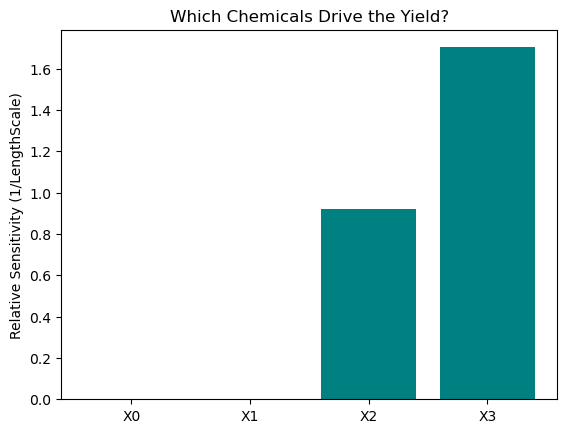

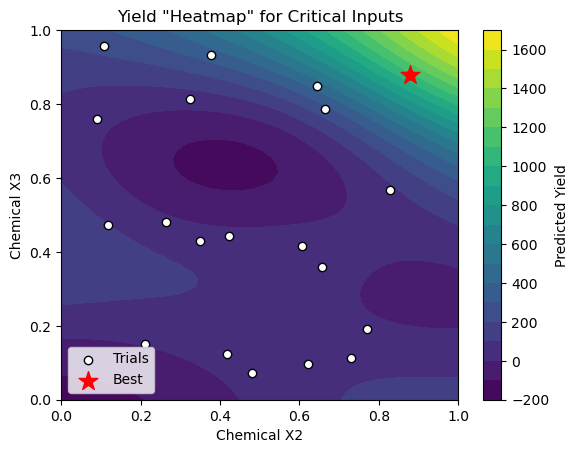

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Feature Sensitivity (Length Scales)
# We plot 1/Length_Scale because a higher value = higher importance
lscales = gp.kernel_.k2.length_scale
names = ['X0', 'X1', 'X2', 'X3']

plt.bar(names, 1/lscales, color='teal')
plt.ylabel('Relative Sensitivity (1/LengthScale)')
plt.title('Which Chemicals Drive the Yield?')
plt.show()

# 2. Response Surface (X2 vs X3)
# Fix X0 and X1 at your best point's coordinates
x_best = X[np.argmax(y)]
grid = np.linspace(0, 1, 50)
X2, X3 = np.meshgrid(grid, grid)

# Prepare prediction grid
points = np.zeros((2500, 4))
points[:, 0], points[:, 1] = x_best[0], x_best[1]
points[:, 2], points[:, 3] = X2.ravel(), X3.ravel()

Z = gp.predict(points).reshape(50, 50)

# Plotting
plt.contourf(X2, X3, Z, levels=20, cmap='viridis')
plt.colorbar(label='Predicted Yield')
plt.scatter(X[:, 2], X[:, 3], c='white', edgecolors='black', label='Trials')
plt.scatter(x_best[2], x_best[3], c='red', marker='*', s=200, label='Best')
plt.xlabel('Chemical X2')
plt.ylabel('Chemical X3')
plt.legend()
plt.title('Yield "Heatmap" for Critical Inputs')
plt.show()

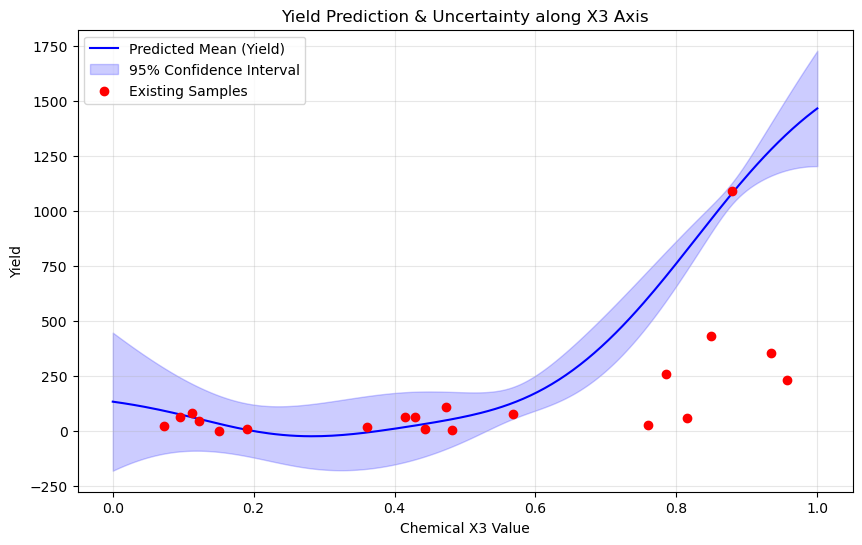

In [39]:
# Create a range for X3 (0 to 1)
x3_axis = np.linspace(0, 1, 200).reshape(-1, 1)

# Fix other variables at Sample 16 values
x_fixed = X[np.argmax(y)].copy()
test_points = np.tile(x_fixed, (200, 1))
test_points[:, 3] = x3_axis.flatten()  # Replace X3 column with the range

# Predict mean and standard deviation
mu, sigma = gp.predict(test_points, return_std=True)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(x3_axis, mu, 'b-', label='Predicted Mean (Yield)')
plt.fill_between(x3_axis.flatten(), 
                 mu - 2*sigma, mu + 2*sigma, 
                 color='blue', alpha=0.2, label='95% Confidence Interval')

# Plot the training points (projected onto X3)
plt.scatter(X[:, 3], y, c='red', label='Existing Samples', zorder=5)

plt.xlabel('Chemical X3 Value')
plt.ylabel('Yield')
plt.title('Yield Prediction & Uncertainty along X3 Axis')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

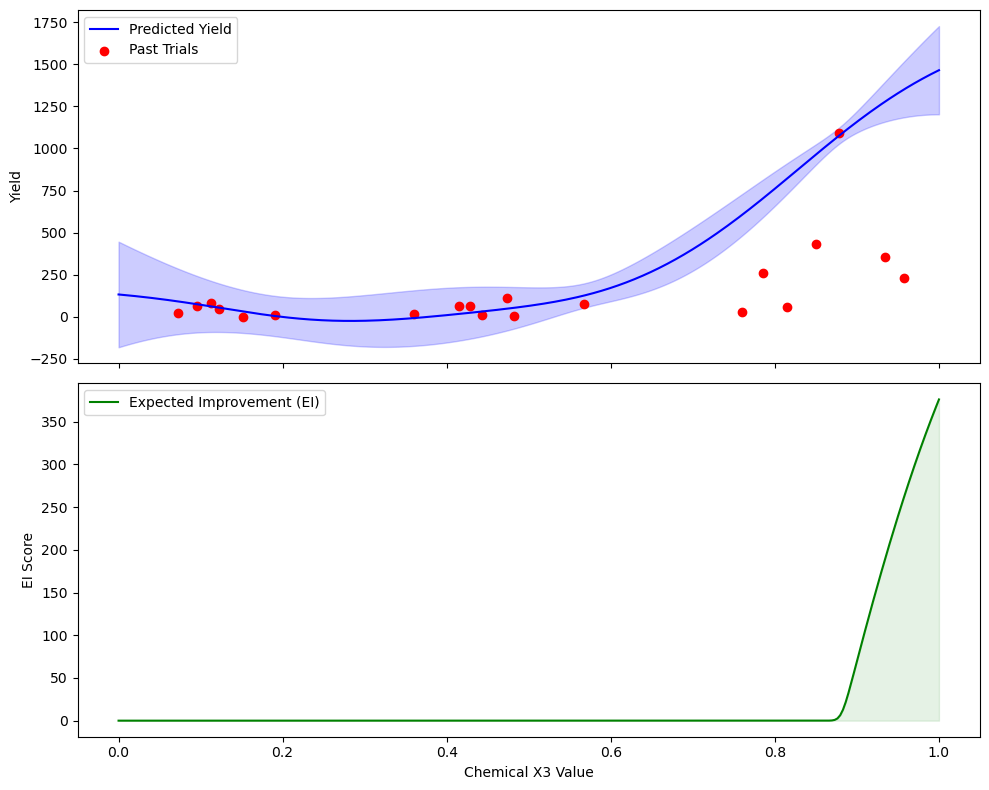

In [40]:
from scipy.stats import norm

# 1. Setup the 1D Slice
x3_range = np.linspace(0, 1, 300).reshape(-1, 1)
x_slice = np.tile(X[np.argmax(y)], (300, 1))
x_slice[:, 3] = x3_range.flatten()

# 2. Get Predictions
mu, sigma = gp.predict(x_slice, return_std=True)
y_max = np.max(y)

# 3. Calculate Expected Improvement (EI) for the plot
z = (mu - y_max) / sigma
ei = (mu - y_max) * norm.cdf(z) + sigma * norm.pdf(z)

# 4. Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Top Plot: Mean and Uncertainty
ax1.plot(x3_range, mu, 'b-', label='Predicted Yield')
ax1.fill_between(x3_range.flatten(), mu - 2*sigma, mu + 2*sigma, color='blue', alpha=0.2)
ax1.scatter(X[:, 3], y, c='red', label='Past Trials')
ax1.set_ylabel('Yield')
ax1.legend()

# Bottom Plot: Acquisition Function (The "Motivation")
ax2.plot(x3_range, ei, 'g-', label='Expected Improvement (EI)')
ax2.fill_between(x3_range.flatten(), 0, ei, color='green', alpha=0.1)
ax2.set_ylabel('EI Score')
ax2.set_xlabel('Chemical X3 Value')
ax2.legend()

plt.tight_layout()
plt.show()